In [ ]:
import torch

from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display

In [4]:
print(Path("../data").resolve())

C:\Users\금정산2-PC16\Desktop\NS-Project\data


In [5]:
# data.yaml 경로 확인

DATA_YAML = Path("../data/data.yaml").resolve()

print(DATA_YAML)
print(DATA_YAML.exists())

C:\Users\금정산2-PC16\Desktop\NS-Project\data\data.yaml
True


In [6]:
# YOLO 모델 불러오기
# n 모델은 가장 가벼워서 첫 실험용으로 적합

model = YOLO("yolov8n.pt")

In [7]:
# # 1차 베이스라이 학습

# results = model.train(
#     data="../data/data.yaml",
#     epochs=30,
#     imgsz=640,      # 입력 이미지 크기 640*640으로 리사이즈 후 학습
#     batch=4,        # 한 번에 몇 장의 이미지를 학습, batch=4 → 이미지 4장을 묶어서 학습
#     device="cpu",
#     workers=0,      # 데이터 로딩 프로세스 개수, Windows에서는 workers=0 이 가장 안정적
#     name="ns_yolov8n_cpu_baseline"
# )

In [8]:
import sys
import torch

print("Python :", sys.executable)
print("Torch :", torch.__version__)
print("CUDA :", torch.cuda.is_available())

Python : c:\Users\금정산2-PC16\Desktop\NS-Project\.venv\Scripts\python.exe
Torch : 2.5.1+cu121
CUDA : True


In [9]:
print("PyTorch :", torch.__version__)
print("CUDA 사용 가능 :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA :", torch.version.cuda)

PyTorch : 2.5.1+cu121
CUDA 사용 가능 : True
GPU : NVIDIA GeForce RTX 2070 SUPER
CUDA : 12.1


In [10]:
# 1차 베이스라인 학습 - GPU 버전으로 재실행

results = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    name="ns_yolov8n_gpu_baseline"
)

New https://pypi.org/project/ultralytics/8.4.67 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.66  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\2-PC16\Desktop\NS-Project\data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, m

In [15]:
# 학습 결과 폴더 확인

runs_dir = Path("../runs/detect/ns_yolov8n_gpu_baseline")

print(runs_dir.exists())
print(list(runs_dir.iterdir()))

True
[WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/args.yaml'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/BoxF1_curve.png'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/BoxPR_curve.png'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/BoxP_curve.png'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/BoxR_curve.png'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/confusion_matrix.png'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/confusion_matrix_normalized.png'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/labels.jpg'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/results.csv'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/results.png'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/train_batch0.jpg'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/train_batch1.jpg'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/train_batch1600.jpg'), WindowsPath('../runs/detect/ns_yolov8n_gpu_baseline/train_batch16

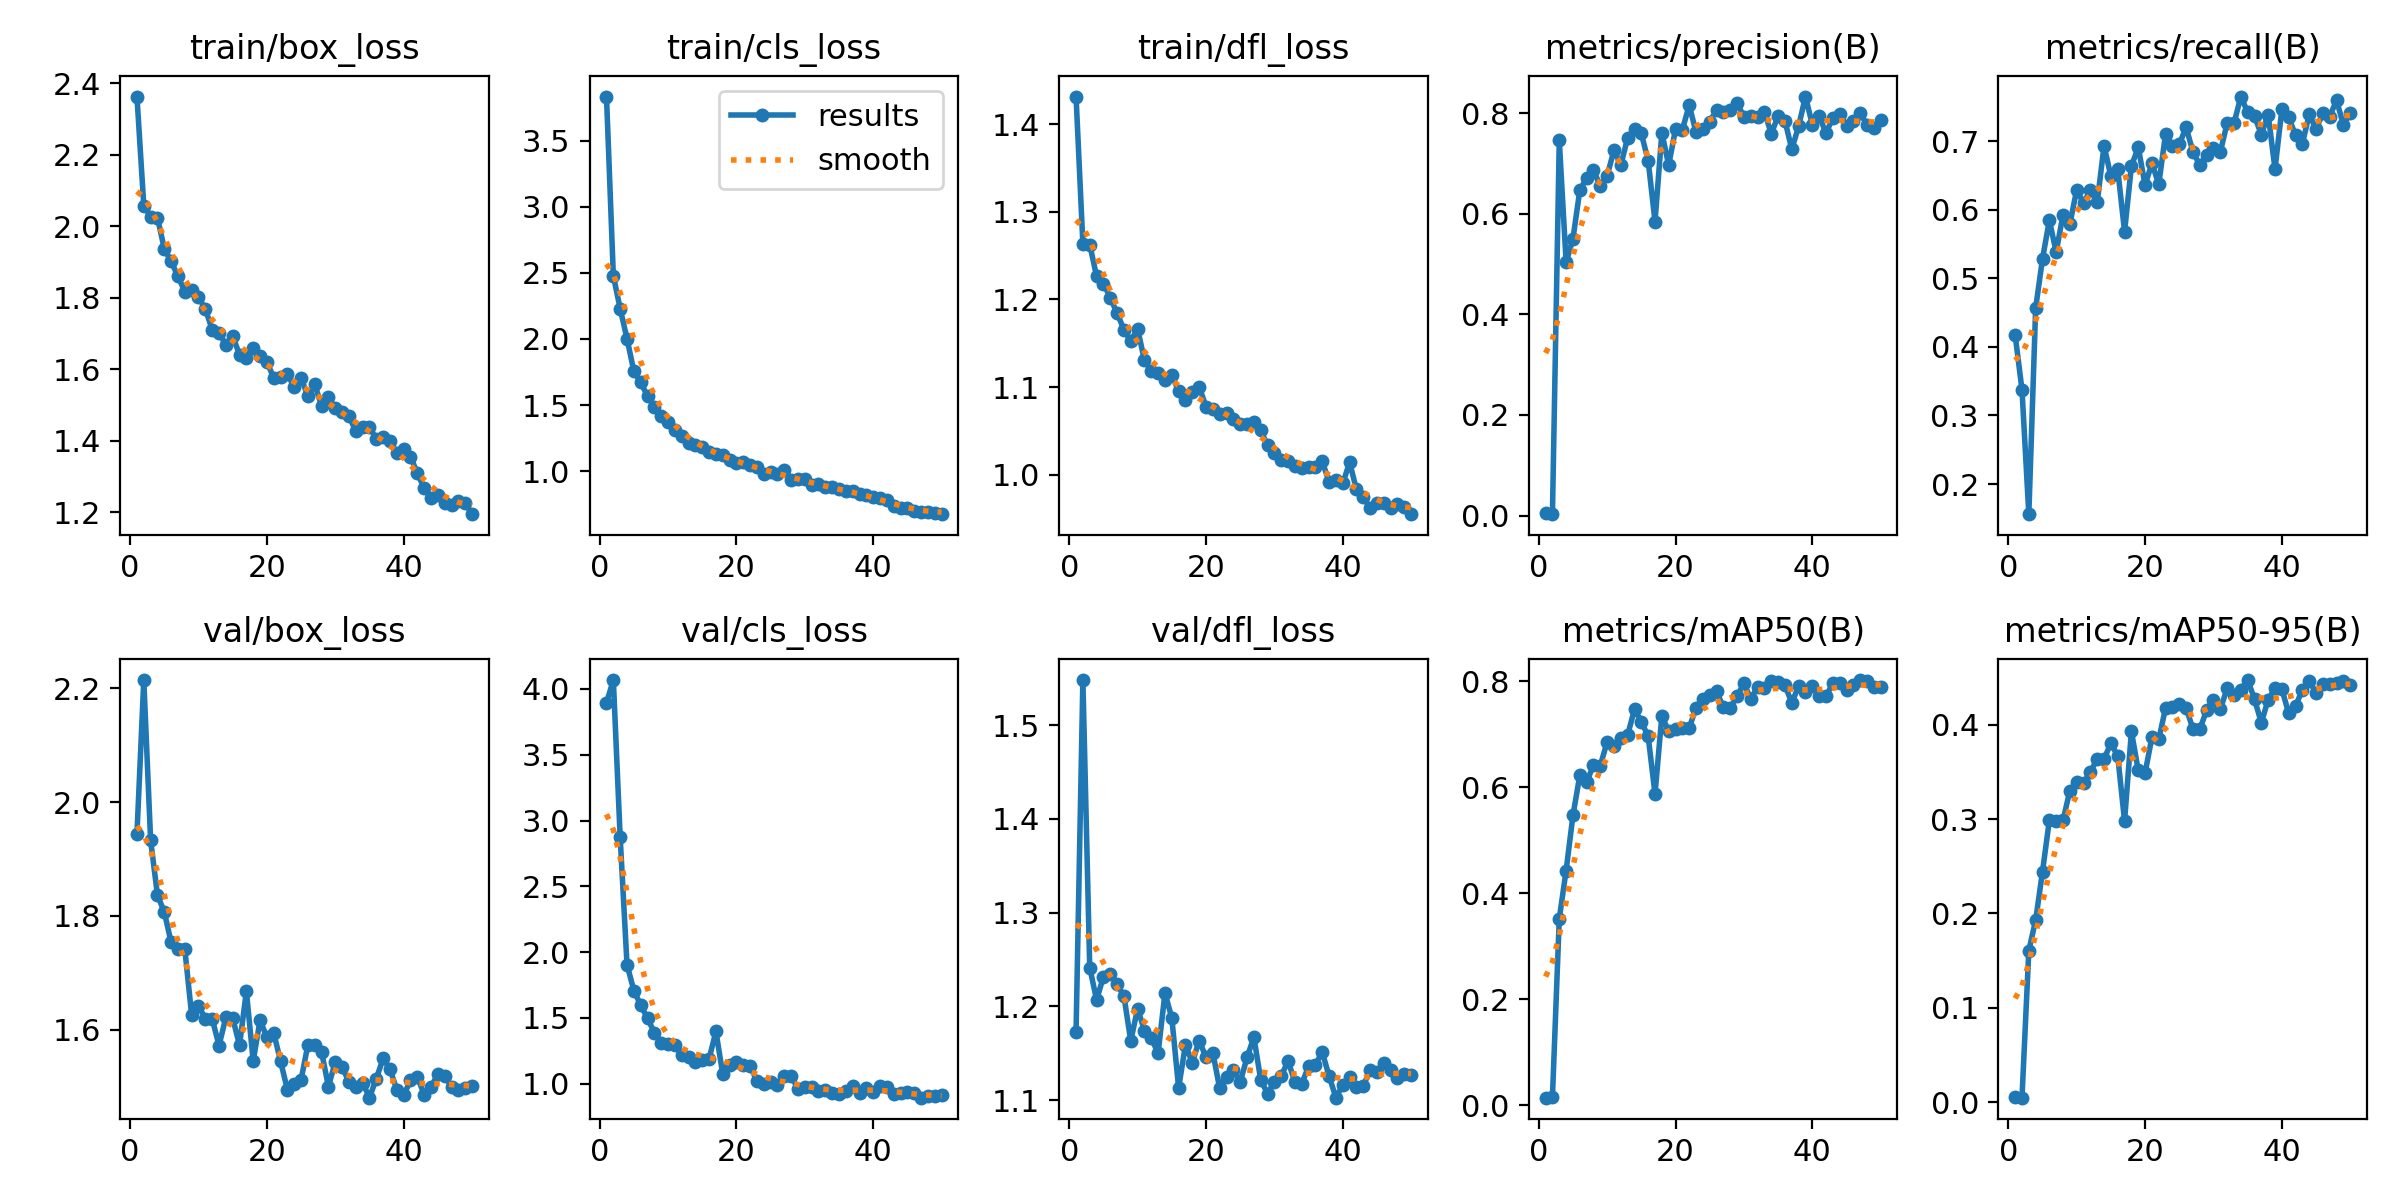

In [17]:
display(Image(filename="../runs/detect/ns_yolov8n_gpu_baseline/results.png"))

In [18]:
# 2차 실험용 모델을 새로 불러오기
model_960 = YOLO("yolov8n.pt")

results_960 = model_960.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=960,
    batch=8,
    device=0,
    workers=4,
    name="ns_yolov8n_960"
)

New https://pypi.org/project/ultralytics/8.4.67 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.66  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\2-PC16\Desktop\NS-Project\data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mo

In [20]:
from pathlib import Path

print(Path.cwd())

best_model = Path("../runs/detect/ns_yolov8n_gpu_baseline/weights/best.pt")

print(best_model.exists())
print(best_model.resolve())

c:\Users\금정산2-PC16\Desktop\NS-Project\notebooks
True
C:\Users\금정산2-PC16\Desktop\NS-Project\runs\detect\ns_yolov8n_gpu_baseline\weights\best.pt


In [22]:
PROJECT_ROOT = Path.cwd().parent

BEST_MODEL = PROJECT_ROOT / "runs" / "detect" / "ns_yolov8n_gpu_baseline" / "weights" / "best.pt"

model_960 = YOLO(str(BEST_MODEL))


results_960 = model_960.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=960,
    batch=8,
    device=0,
    workers=4,
    name="ns_yolov8n_960_finetune"
)

New https://pypi.org/project/ultralytics/8.4.67 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.66  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\2-PC16\Desktop\NS-Project\data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=c:\Users\2-PC16\Desktop\NS-Pro

In [23]:
PROJECT_ROOT = Path.cwd().parent

RUN_640 = PROJECT_ROOT / "runs" / "detect" / "ns_yolov8n_gpu_baseline"
RUN_960 = PROJECT_ROOT / "runs" / "detect" / "ns_yolov8n_960"

BEST_640 = RUN_640 / "weights" / "best.pt"
BEST_960 = RUN_960 / "weights" / "best.pt"

TEST_IMAGES = PROJECT_ROOT / "data" / "test" / "images"

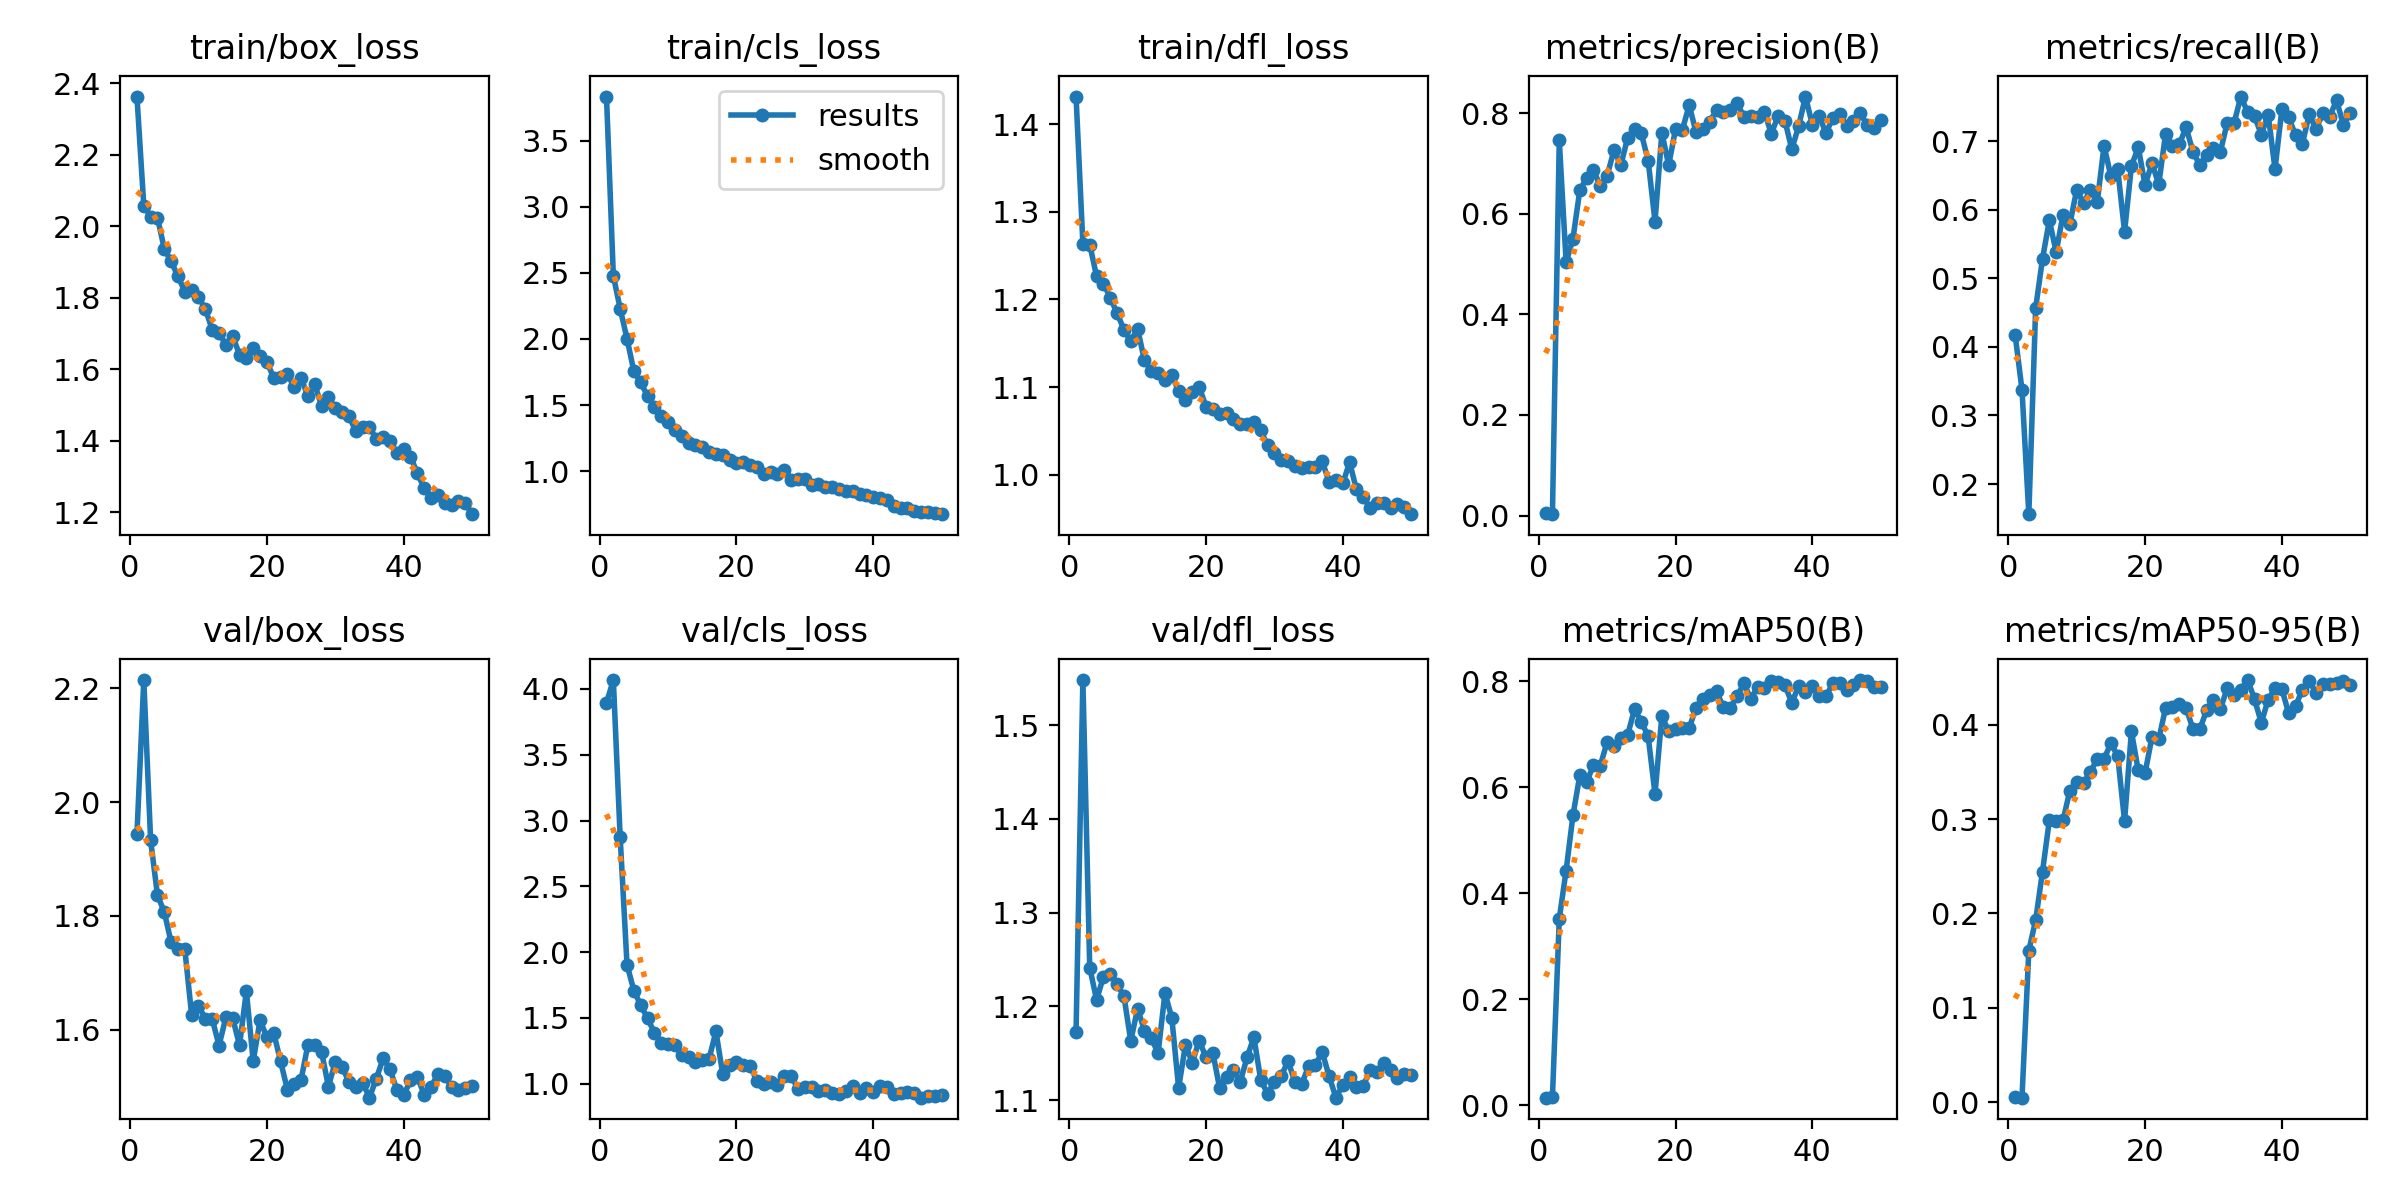

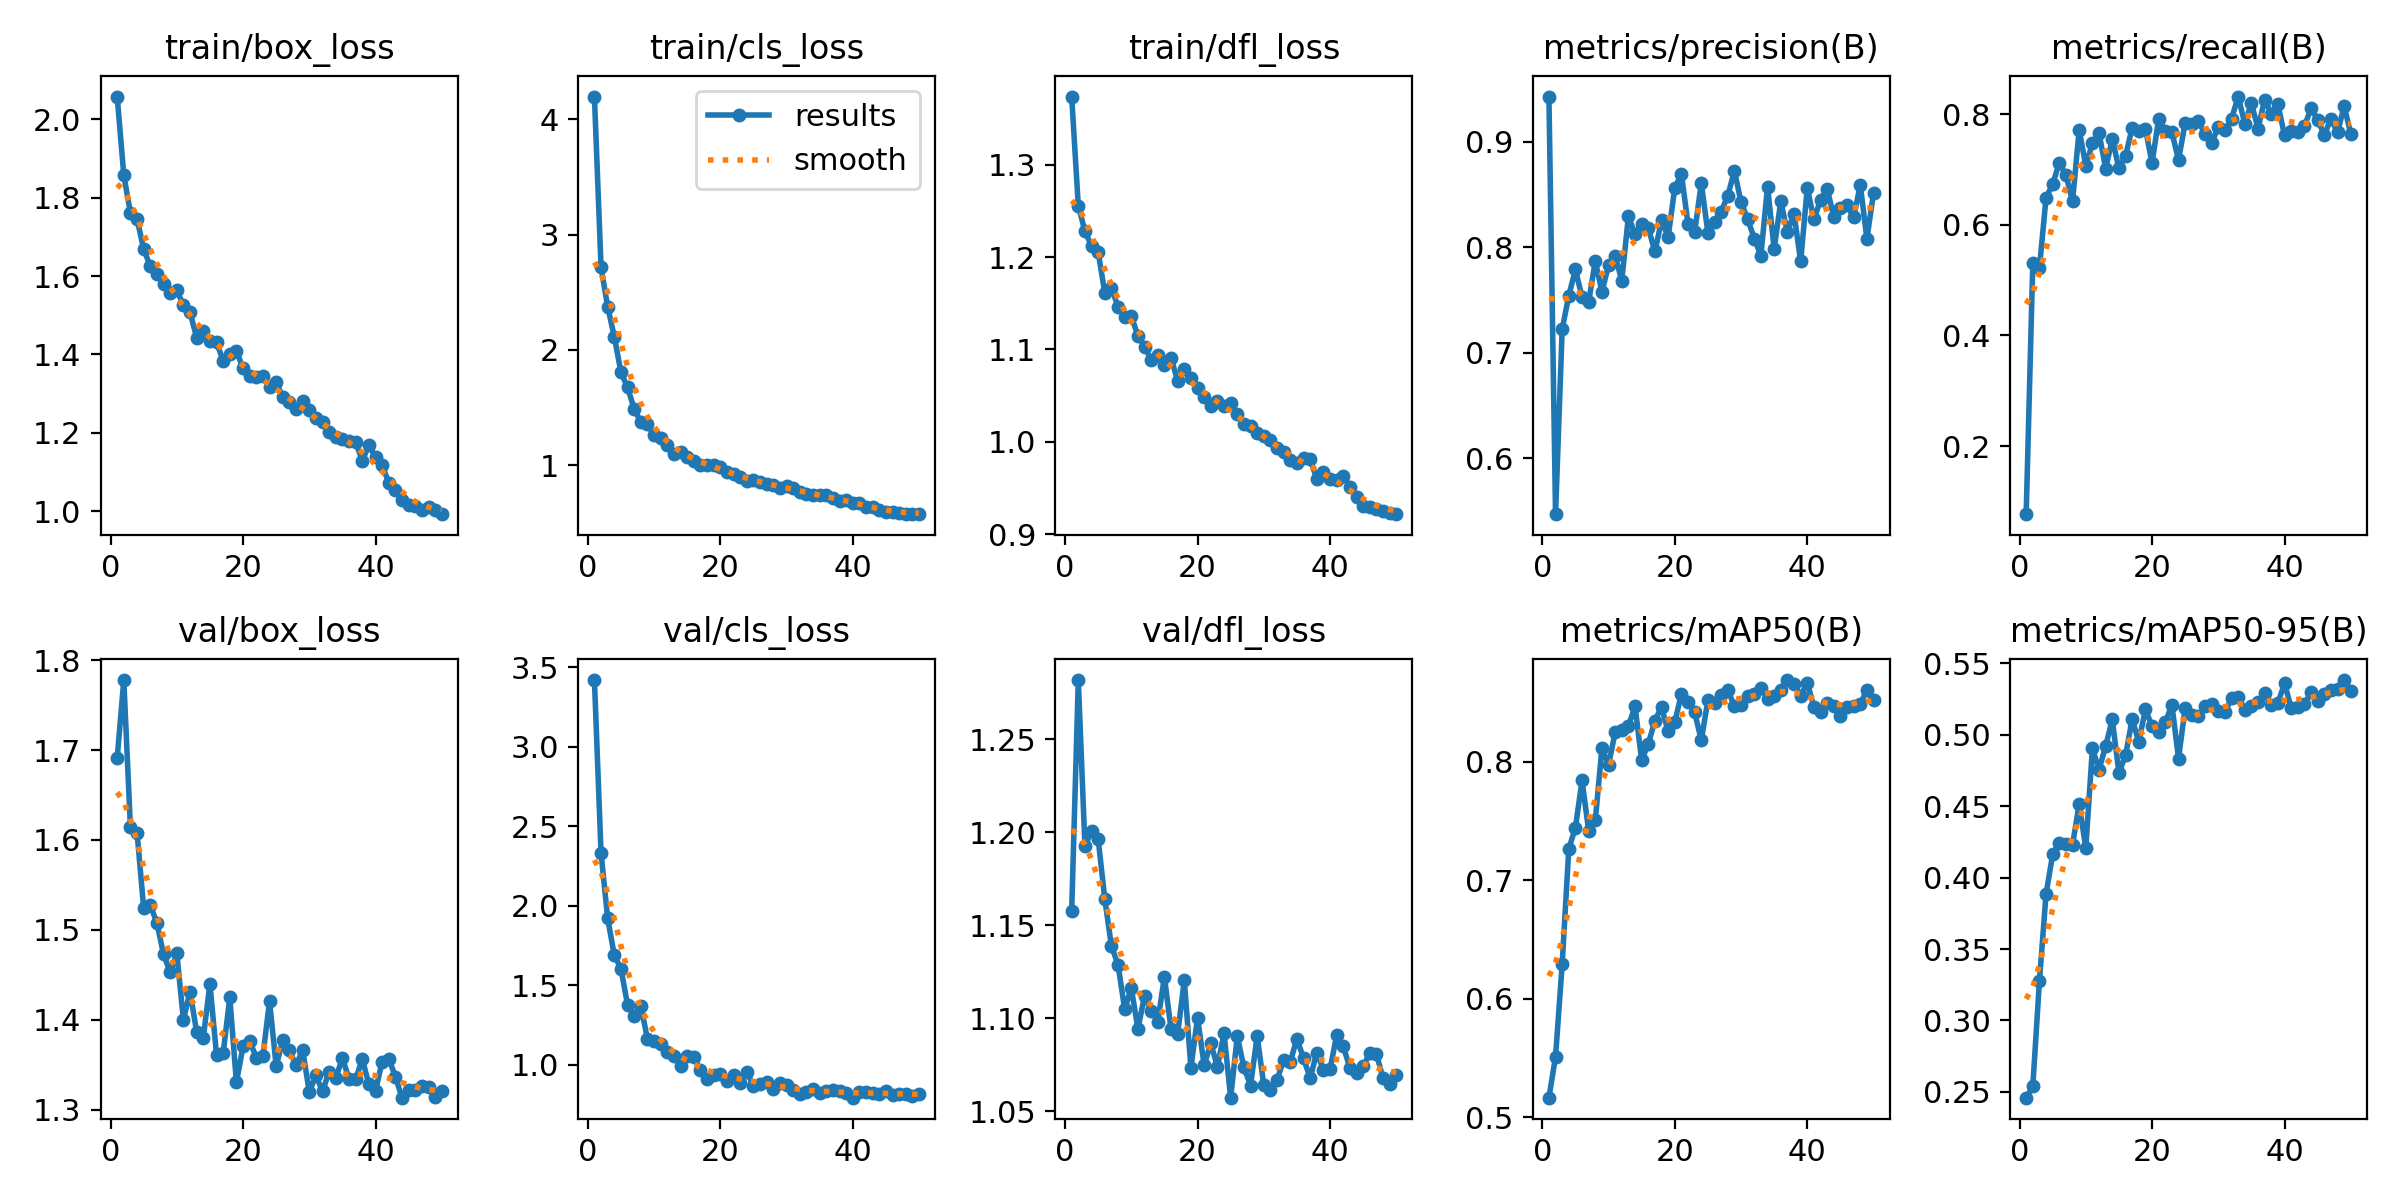

In [24]:
display(Image(filename=str(RUN_640 / "results.png")))
display(Image(filename=str(RUN_960 / "results.png")))

In [25]:
best_640 = YOLO(str(BEST_640))
best_960 = YOLO(str(BEST_960))

In [26]:
metrics_640 = best_640.val(
    data=str(DATA_YAML),
    imgsz=640,
    device=0
)

metrics_960 = best_960.val(
    data=str(DATA_YAML),
    imgsz=960,
    device=0
)

Ultralytics 8.4.66  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2301.0436.0 MB/s, size: 680.4 KB)
val: Scanning C:\Users\금정산2-PC16\Desktop\NS-Project\data\valid\labels.cache... 136 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 136/136  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.3it/s 4.0s0.1s
                   all        136        321      0.825      0.713      0.794      0.446
        user_character        122        169       0.79      0.775      0.823      0.488
               user_id        123        152      0.861       0.65      0.764      0.403
Speed: 1.6ms preprocess, 3.8ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to C:\Users\2-PC16\Desktop\NS-Project\runs\detect\val
Ultralytics 8.4.66  Python-3.12.13 torch-2

### mAP50

mAP50은 객체 탐지 모델이 객체를 얼마나 잘 찾아내는지를 평가하는 지표이다. 예측한 Bounding Box와 실제 Bounding Box의 IoU가 0.50 이상이면 정답으로 인정한다. 따라서 객체를 찾았는지 여부에 초점을 맞춘 성능 지표라고 볼 수 있다.

이번 실험에서는 입력 이미지 크기를 640에서 960으로 증가시킨 결과 mAP50이 **0.808 → 0.856**으로 향상되었다. 이는 모델이 객체를 더 높은 비율로 탐지할 수 있게 되었음을 의미한다.

---

### mAP50-95

mAP50-95는 객체를 찾는 능력뿐만 아니라 Bounding Box를 얼마나 정확한 위치에 예측했는지까지 평가하는 지표이다. IoU 0.50부터 0.95까지 다양한 기준에서 성능을 측정한 후 평균을 계산한다.

실험 결과 mAP50-95는 **0.466 → 0.543**으로 향상되었다. 이는 객체 탐지 성능뿐만 아니라 위치 예측 정확도도 함께 개선되었음을 의미한다.

---

### 실험 결과 해석

EDA 결과 `user_id`는 `user_character`보다 훨씬 작은 객체로 확인되었다. 따라서 입력 이미지 크기를 640에서 960으로 증가시켜 더 많은 픽셀 정보를 제공한 결과, 특히 작은 객체인 `user_id` 탐지 성능이 향상되었다.

최종적으로 **YOLOv8n + imgsz=960** 모델이 Precision, Recall, mAP50, mAP50-95 모두에서 더 우수한 성능을 보였으며, 이번 데이터셋에서는 가장 좋은 성능을 보인 모델로 확인되었다.


In [27]:
model = YOLO(str(BEST_960))

results = model.predict(
    source=str(TEST_IMAGES),
    conf=0.5,
    save=True,
    device=0
)


image 1/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_115450606.jpg: 512x960 1 user_character, 1 user_id, 23.2ms
image 2/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_141339663.jpg: 512x960 (no detections), 6.2ms
image 3/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_222002013.jpg: 512x960 1 user_character, 1 user_id, 7.1ms
image 4/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_231808909.jpg: 512x960 1 user_character, 7.2ms
image 5/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_234814460.jpg: 512x960 1 user_character, 1 user_id, 5.6ms
image 6/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0308_005112729.jpg: 512x960 1 user_character, 1 user_id, 5.8ms
image 7/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0308_213117869.jpg: 512x960 1 user_id, 5.8ms
image 8/137 c:\Users\2-PC16\Desktop\NS-Projec

In [29]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

detect_dir = PROJECT_ROOT / "runs" / "detect"

for p in detect_dir.iterdir():
    print(p.name)

ns_yolov8n_960
ns_yolov8n_960_finetune
ns_yolov8n_cpu_baseline
ns_yolov8n_gpu_baseline
predict
val
val-2


In [30]:
run_dir = PROJECT_ROOT / "runs" / "detect" / "ns_yolov8n_960"

print(run_dir.exists())

True


In [31]:
PROJECT_ROOT = Path.cwd().parent

BEST_960 = PROJECT_ROOT / "runs" / "detect" / "ns_yolov8n_960" / "weights" / "best.pt"

print(BEST_960.exists())
print(BEST_960)

model = YOLO(str(BEST_960))

True
c:\Users\금정산2-PC16\Desktop\NS-Project\runs\detect\ns_yolov8n_960\weights\best.pt


In [32]:
model = YOLO(str(BEST_960))

In [33]:
TEST_IMAGES = PROJECT_ROOT / "data" / "test" / "images"

results = model.predict(
    source=str(TEST_IMAGES),
    conf=0.5,
    save=True,
    device=0
)


image 1/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_115450606.jpg: 512x960 1 user_character, 1 user_id, 44.3ms
image 2/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_141339663.jpg: 512x960 (no detections), 5.9ms
image 3/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_222002013.jpg: 512x960 1 user_character, 1 user_id, 5.5ms
image 4/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_231808909.jpg: 512x960 1 user_character, 6.3ms
image 5/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_234814460.jpg: 512x960 1 user_character, 1 user_id, 5.7ms
image 6/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0308_005112729.jpg: 512x960 1 user_character, 1 user_id, 6.3ms
image 7/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0308_213117869.jpg: 512x960 1 user_id, 5.6ms
image 8/137 c:\Users\2-PC16\Desktop\NS-Projec

In [36]:
# 640 vs 960 성능 비교

print(metrics_640.box.map50)
print(metrics_960.box.map50)
print("========================")
print(metrics_640.box.map)
print(metrics_960.box.map)

0.793841902821039
0.8606541339375008
0.4455079902056204
0.5400428892412111


In [37]:
results = model.predict(
    source=str(TEST_IMAGES),
    conf=0.5,
    save=True,
    device=0
)


image 1/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_115450606.jpg: 512x960 1 user_character, 1 user_id, 137.5ms
image 2/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0304_141339663.jpg: 512x960 (no detections), 49.9ms
image 3/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_222002013.jpg: 512x960 1 user_character, 1 user_id, 6.0ms
image 4/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_231808909.jpg: 512x960 1 user_character, 6.3ms
image 5/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0307_234814460.jpg: 512x960 1 user_character, 1 user_id, 8.3ms
image 6/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0308_005112729.jpg: 512x960 1 user_character, 1 user_id, 5.9ms
image 7/137 c:\Users\2-PC16\Desktop\NS-Project\data\test\images\ScreenShot2024_0308_213117869.jpg: 512x960 1 user_id, 5.5ms
image 8/137 c:\Users\2-PC16\Desktop\NS-Proj

In [38]:
# ==================================================
# YOLOv8s 모델 학습
# 목적 : 모델 크기 증가에 따른 성능 향상 확인
# ==================================================

model_s = YOLO("yolov8s.pt")

results_s = model_s.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=960,
    batch=4,      # RTX 2070 SUPER 8GB 고려
    device=0,
    workers=4,
    name="ns_yolov8s_960"
)

New https://pypi.org/project/ultralytics/8.4.67 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.66  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\2-PC16\Desktop\NS-Project\data\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mo

True


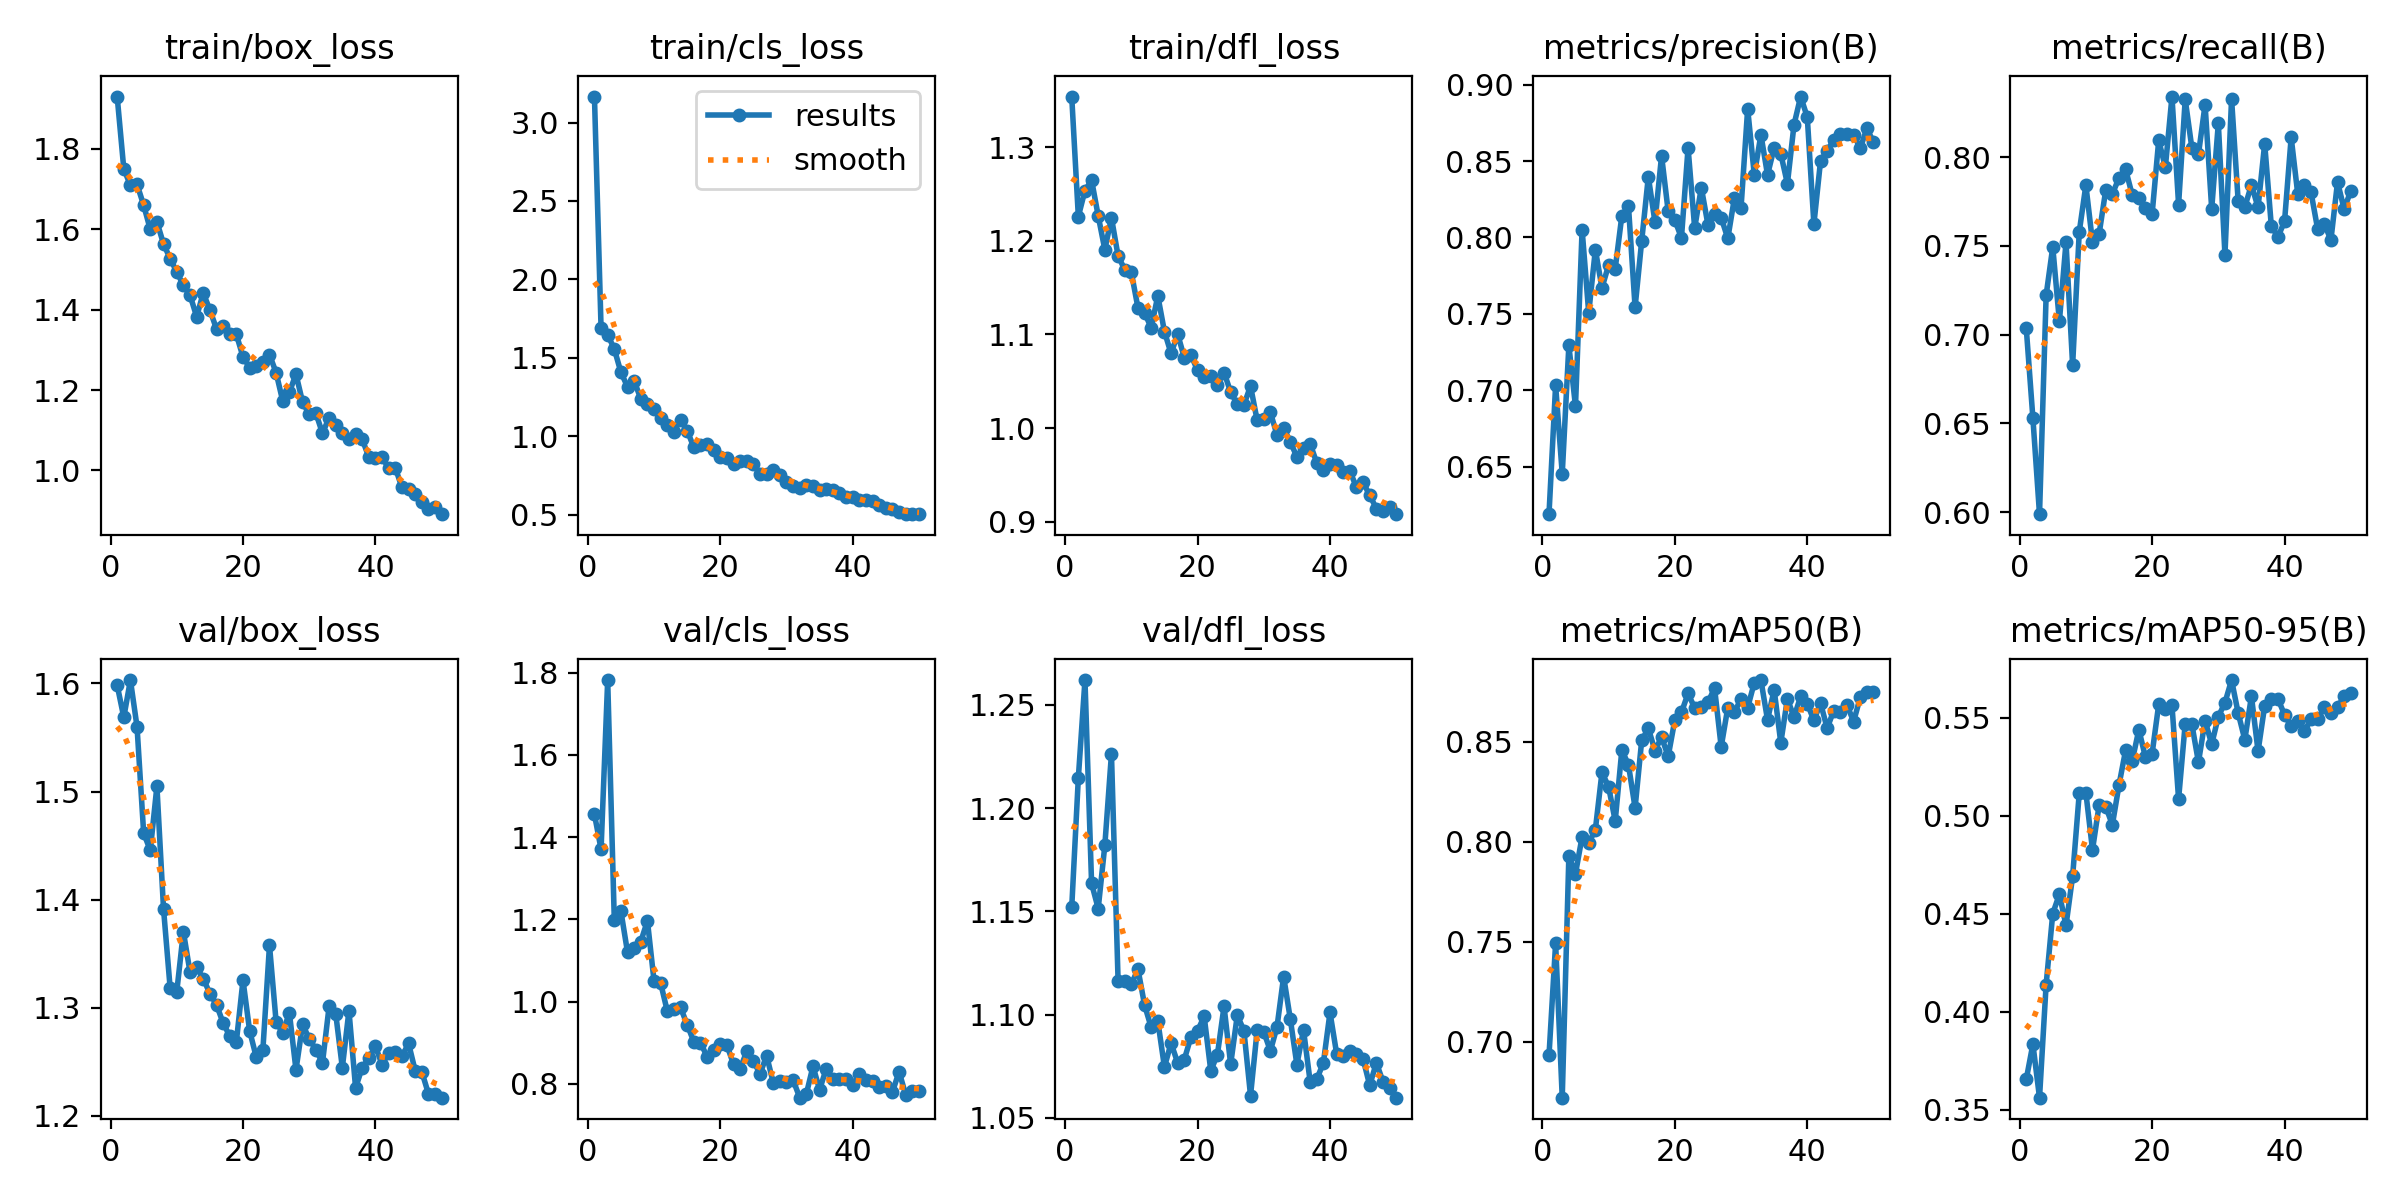

In [39]:
# ==================================================
# YOLOv8s-960 학습 결과 그래프 확인
# ==================================================

from IPython.display import Image, display

result_img_s = PROJECT_ROOT / "runs" / "detect" / "ns_yolov8s_960" / "results.png"

print(result_img_s.exists())
display(Image(filename=str(result_img_s)))

In [40]:
# ==================================================
# YOLOv8s-960 best 모델 검증
# ==================================================

best_s = YOLO(
    str(PROJECT_ROOT / "runs" / "detect" / "ns_yolov8s_960" / "weights" / "best.pt")
)

metrics_s = best_s.val(
    data=str(DATA_YAML),
    imgsz=960,
    device=0
)

print("mAP50    :", metrics_s.box.map50)
print("mAP50-95 :", metrics_s.box.map)

Ultralytics 8.4.66  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2070 SUPER, 8192MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 2708.9528.1 MB/s, size: 680.4 KB)
val: Scanning C:\Users\금정산2-PC16\Desktop\NS-Project\data\valid\labels.cache... 136 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 136/136  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.8it/s 5.1s0.3ss
                   all        136        321      0.839      0.836      0.879      0.566
        user_character        122        169      0.868      0.817       0.88      0.542
               user_id        123        152      0.809      0.855      0.878      0.589
Speed: 3.9ms preprocess, 6.5ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to C:\Users\2-PC16\Desktop\NS-Project\runs\detect\val-3
mAP50    : 0.879004209702356
mAP50-95

In [41]:
# ==================================================
# 3개 모델 성능 비교표 생성
# ==================================================

import pandas as pd

compare_df = pd.DataFrame({
    "Model": [
        "YOLOv8n-640",
        "YOLOv8n-960",
        "YOLOv8s-960"
    ],
    "mAP50": [
        metrics_640.box.map50,
        metrics_960.box.map50,
        metrics_s.box.map50
    ],
    "mAP50-95": [
        metrics_640.box.map,
        metrics_960.box.map,
        metrics_s.box.map
    ]
})

compare_df

,Model,mAP50,mAP50-95
0,YOLOv8n-640,0.793842,0.445508
1,YOLOv8n-960,0.860654,0.540043
2,YOLOv8s-960,0.879004,0.565686


# 모델링 실험 결과 정리

## 실험 목적

게임 이미지 내

- 캐릭터(user_character)
- 닉네임(user_id)

탐지 성능을 향상시키기 위해

1. 입력 해상도 증가 효과 검증
2. 모델 크기 증가 효과 검증

을 수행하였다.

---

## 실험 1 : YOLOv8n + 640 (Baseline)

### 설정

```python
imgsz=640
batch=16
epochs=50
```

### 결과

| Metric | Score |
|----------|----------:|
| mAP50 | 0.7938 |
| mAP50-95 | 0.4455 |
```

기본 성능 확인용 베이스라인 모델

---

## 실험 2 : YOLOv8n + 960

### 목적

입력 이미지 해상도 증가 효과 검증

### 설정

```python
imgsz=960
batch=8
epochs=50
```

### 결과

| Metric | Score |
|----------|----------:|
| mAP50 | 0.8607 |
| mAP50-95 | 0.5400 |

### 성능 변화

| Metric | 향상폭 |
|----------|----------:|
| mAP50 | +0.0668 |
| mAP50-95 | +0.0945 |

### 해석

입력 해상도를 증가시키자 작은 객체인 캐릭터와 닉네임 탐지 성능이 크게 향상되었다.

---

## 실험 3 : YOLOv8s + 960

### 목적

모델 크기 증가 효과 검증

### 설정

```python
imgsz=960
batch=4
epochs=50
```

### 결과

| Metric | Score |
|----------|----------:|
| mAP50 | 0.8790 |
| mAP50-95 | 0.5657 |

### 성능 변화

| Metric | 향상폭 |
|----------|----------:|
| mAP50 | +0.0183 |
| mAP50-95 | +0.0257 |

### 해석

모델 크기를 증가시키자 성능은 향상되었지만, 해상도 증가에 비해 향상 폭은 상대적으로 작았다.

---

## 모델 성능 비교

| 모델 | mAP50 | mAP50-95 |
|--------|--------:|--------:|
| YOLOv8n-640 | 0.7938 | 0.4455 |
| YOLOv8n-960 | 0.8607 | 0.5400 |
| YOLOv8s-960 | **0.8790** | **0.5657** |

---

## 실험 결과 분석

### 해상도 증가 효과

```text
YOLOv8n-640
↓
YOLOv8n-960
```

- mAP50 +0.0668
- mAP50-95 +0.0945

가장 큰 성능 향상을 확인

---

### 모델 크기 증가 효과

```text
YOLOv8n-960
↓
YOLOv8s-960
```

- mAP50 +0.0183
- mAP50-95 +0.0257

성능은 향상되었으나 해상도 증가 대비 효과는 작음

---

## 최종 결론

이번 데이터셋에서는 모델 크기 증가보다 입력 해상도 증가가 성능 향상에 더 큰 영향을 미쳤다.

### 최고 성능 모델

```text
YOLOv8s-960
```

| Metric | Score |
|----------|----------:|
| mAP50 | 0.8790 |
| mAP50-95 | 0.5657 |

최종 모델로 선정하였다.